In [1]:
import os
import pandas as pd
import numpy as np
import time

from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

import traceback
import psutil as ps
import warnings
warnings.filterwarnings("ignore")

In [2]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/data/processed")
weather_data = pd.read_csv("clean_weather_data.csv", parse_dates = ["Date"])
weather_data.head()

,Date,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,...,Rolling std of Surface_pressure,Rolling std of Pressure_msl,Day_of-year,Sine_Day_of-year,Cose_Day_of-year,day_of_week,day_of_month,month,quarter,is_weekend
0,2020-01-01 23:00:00,10.3,95,0.0,11.7,17.0,1007.0,1021.7,0,11.629167,...,1.337252,1.297482,1,0.017213,0.999852,2,1,1,1,0
1,2020-01-02 00:00:00,10.8,94,0.0,11.4,20.0,1006.7,1021.3,0,11.837500,...,1.299770,1.275948,2,0.034422,0.999407,3,2,1,1,0
2,2020-01-02 01:00:00,10.4,95,0.0,11.2,18.4,1006.3,1020.9,0,12.033333,...,1.244437,1.239536,2,0.034422,0.999407,3,2,1,1,0
3,2020-01-02 02:00:00,10.3,95,0.0,11.0,18.9,1006.2,1020.8,0,12.212500,...,1.194523,1.203618,2,0.034422,0.999407,3,2,1,1,0
4,2020-01-02 03:00:00,9.8,96,0.0,10.8,18.1,1005.6,1020.3,0,12.379167,...,1.148913,1.175351,2,0.034422,0.999407,3,2,1,1,0


In [3]:
weather_data.set_index("Date",inplace = True)

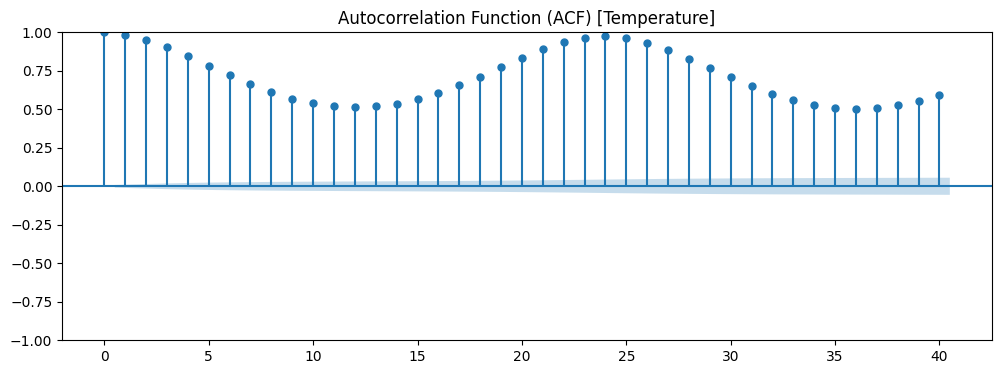

In [4]:
fig_acf = plot_acf(weather_data["Temperature"].dropna(), lags = 40, title = "Autocorrelation Function (ACF) [Temperature]")
fig_acf.set_size_inches(12,4)
plt.show()

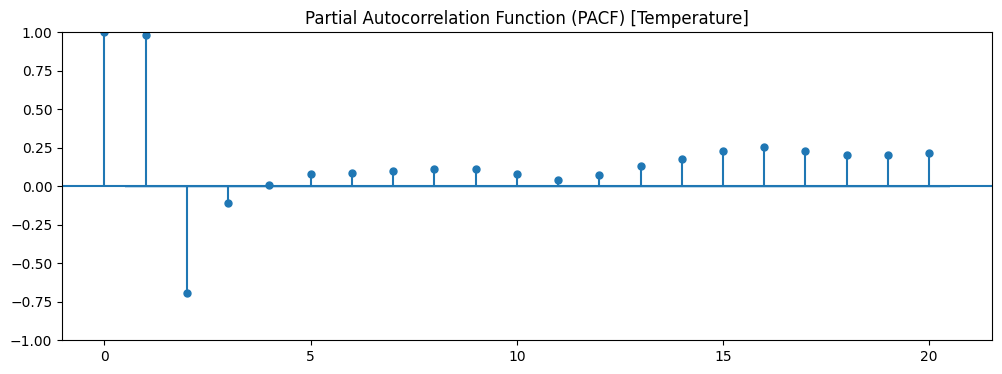

In [5]:
fig_pacf = plot_pacf(weather_data["Temperature"].dropna(), lags=20, title='Partial Autocorrelation Function (PACF) [Temperature]')
fig_pacf.set_size_inches(12,4)
plt.show()

- **There is not any accurate cutoff value and seasionality in both plots**

- **This suggest there is not seasionality in temperature data.**

##### Making data as Seasional data

In [6]:
weather_data["Temperature_seasonal_diff"] = (
    weather_data["Temperature"] - weather_data["Temperature"].shift(24)
)

In [7]:
weekly_temp = weather_data["Temperature"].resample('W').sum()

In [8]:
#weather_data["temp_sqrt"] = np.sqrt(weather_data["Temperature"])

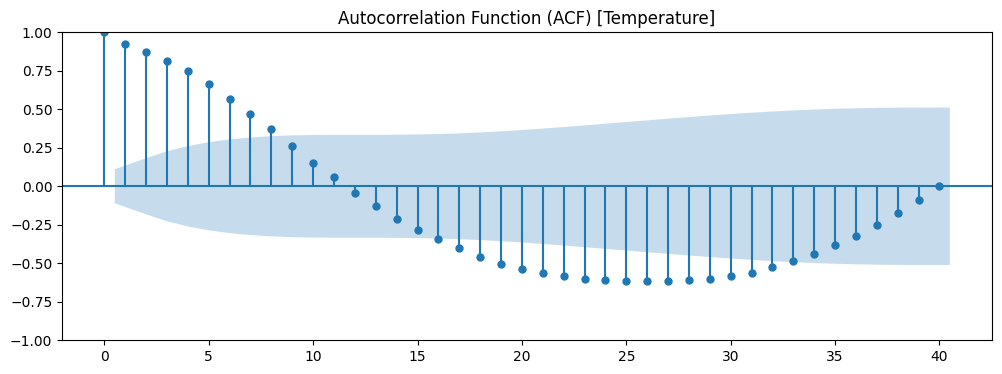

In [9]:
fig_acf = plot_acf(weekly_temp.dropna(), lags = 40, title = "Autocorrelation Function (ACF) [Temperature]")
fig_acf.set_size_inches(12,4)
plt.show()

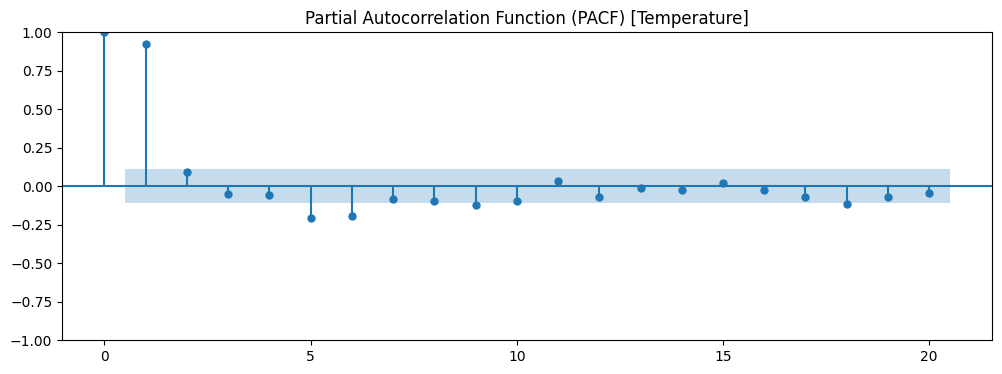

In [10]:
fig_pacf = plot_pacf(weekly_temp.dropna(), lags=20, title='Partial Autocorrelation Function (PACF) [Temperature]')
fig_pacf.set_size_inches(12,4)
plt.show()

- similer to fist one, there is no cuttof value for order for arima, & sarima models

- ** From this Partial Autocorrelation Function (PACF),Autocorrelation Function plot we take order:
- (p,d,q) = (1,0,1) [Non-seasonal parameters]
- (P, D, Q, m) = (1,1,1,4) [Seasonal parameters]

In [11]:
sarima_model = SARIMAX(weekly_temp, 
                       order=(1, 0, 1),           # Non-seasonal parameters
                       seasonal_order=(1, 1, 1, 4),  # Seasonal parameters (P, D, Q, m)
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

In [12]:
sarima_fit = sarima_model.fit(disp=False)

In [13]:
sarima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                       Temperature   No. Observations:                  314
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 4)   Log Likelihood               -2185.483
Date:                           Sun, 12 Jul 2026   AIC                           4380.966
Time:                                   12:43:50   BIC                           4399.551
Sample:                               01-05-2020   HQIC                          4388.401
                                    - 01-04-2026                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9463      0.022     43.743      0.000       0.904       0.989
ma.L1         -0.0161      0.064     -0.253      0.800      -0.141       0.109
ar.S.L4        0.2909      0.057      5.126      0.000       0.180       0.402
ma.S.L4       -1.0001      0.065    -15.341      0.000      -1.128      -0.872
sigma2      9.811e+04    6.6e-07   1.49e+11      0.000    9.81e+04    9.81e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                16.79
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.24   Skew:                            -0.14
Prob(H) (two-sided):                  0.29   Kurtosis:                         4.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.36e+26. Standard errors may be unstable.
"""

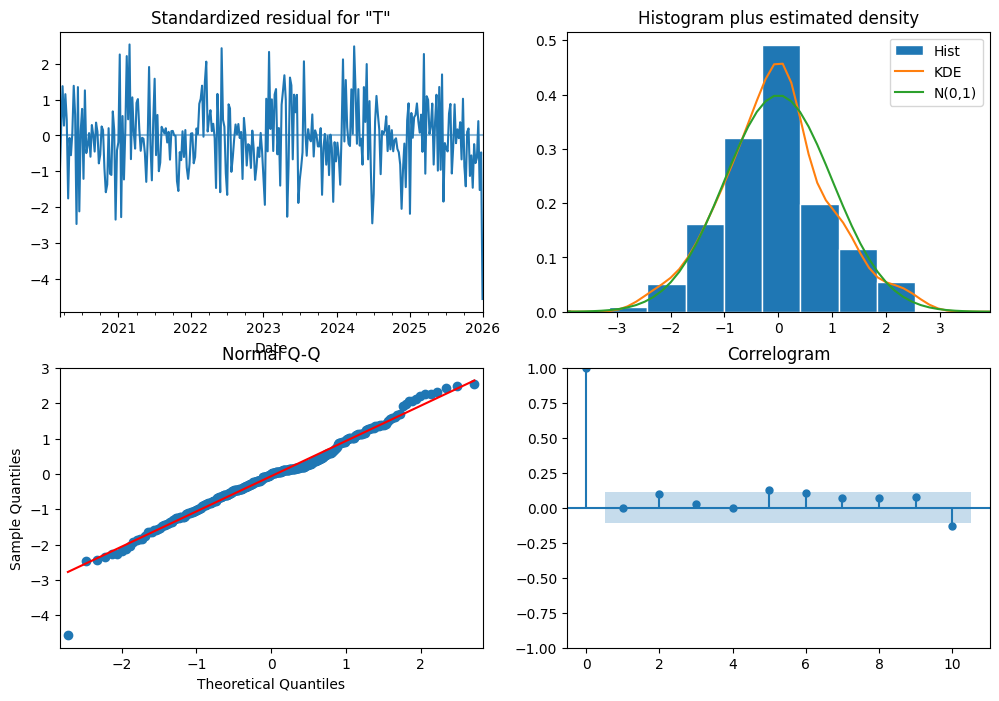

In [14]:
sarima_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

In [15]:
train_data = weekly_temp[:int(0.9*len(weekly_temp))]
test_data = weekly_temp[int(0.9*len(weekly_temp)):]

In [16]:
forecast = sarima_fit.get_forecast(steps=len(test_data))
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [17]:
# Evaluate model performance
mae = mean_absolute_error(test_data, forecast_mean)
rmse = np.sqrt(mean_squared_error(test_data, forecast_mean))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 2354.64
Root Mean Squared Error (RMSE): 2725.42


In [18]:
print(type(test_data))
print(type(forecast_mean))

print(test_data.index)
print(forecast_mean.index)

print(test_data.index.equals(forecast_mean.index))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
DatetimeIndex(['2025-06-01', '2025-06-08', '2025-06-15', '2025-06-22',
               '2025-06-29', '2025-07-06', '2025-07-13', '2025-07-20',
               '2025-07-27', '2025-08-03', '2025-08-10', '2025-08-17',
               '2025-08-24', '2025-08-31', '2025-09-07', '2025-09-14',
               '2025-09-21', '2025-09-28', '2025-10-05', '2025-10-12',
               '2025-10-19', '2025-10-26', '2025-11-02', '2025-11-09',
               '2025-11-16', '2025-11-23', '2025-11-30', '2025-12-07',
               '2025-12-14', '2025-12-21', '2025-12-28', '2026-01-04'],
              dtype='datetime64[ns]', name='Date', freq='W-SUN')
DatetimeIndex(['2026-01-11', '2026-01-18', '2026-01-25', '2026-02-01',
               '2026-02-08', '2026-02-15', '2026-02-22', '2026-03-01',
               '2026-03-08', '2026-03-15', '2026-03-22', '2026-03-29',
               '2026-04-05', '2026-04-12', '2026-04-19', '2026-04-26',
          

In [19]:
model = ARIMA(weekly_temp, order=(1, 0, 1))
model_fit = model.fit()

In [20]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            Temperature   No. Observations:                  314
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -2271.361
Date:                Sun, 12 Jul 2026   AIC                           4550.722
Time:                        12:43:50   BIC                           4565.720
Sample:                    01-05-2020   HQIC                          4556.715
                         - 01-04-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4164.3140    527.938      7.888      0.000    3129.574    5199.054
ar.L1          0.9692      0.014     67.226      0.000       0.941       0.997
ma.L1          0.0216      0.055      0.390      0.697      -0.087       0.130
sigma2      1.089e+05   6897.652     15.794      0.000    9.54e+04    1.22e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.11   Jarque-Bera (JB):                26.65
Prob(Q):                              0.74   Prob(JB):                         0.00
Heteroskedasticity (H):               1.13   Skew:                            -0.30
Prob(H) (two-sided):                  0.54   Kurtosis:                         4.29
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

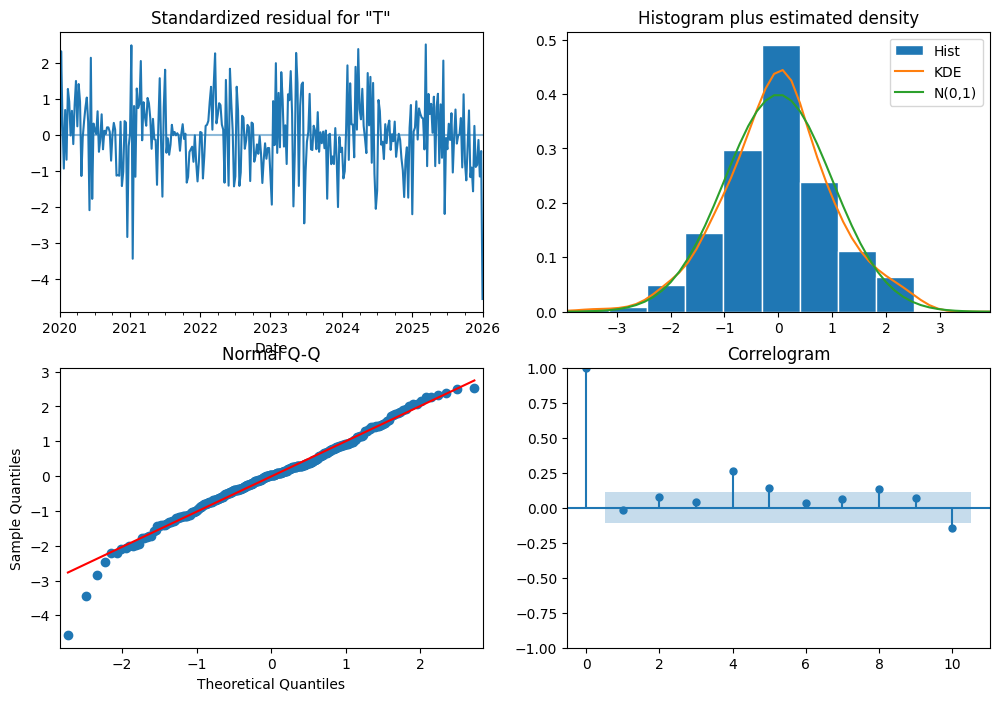

In [21]:
model_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

In [22]:
forecast = model_fit.get_forecast(steps=len(test_data))
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [23]:
# Evaluate model performance
mae = mean_absolute_error(test_data, forecast_mean)
rmse = np.sqrt(mean_squared_error(test_data, forecast_mean))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 2338.10
Root Mean Squared Error (RMSE): 2691.39
